In [36]:
import numpy as np


In [37]:
lake=(0,0)
fire=[(4,4)]
smoke=[(1,2),(3,2)]
boulders=[(3,4),(2,4)]


In [38]:
def terminal(state):
    if tuple(state[1:3]) in fire and state[0]:
        return True
    elif tuple(state[1:3]) in boulders:
        return True 
    else:
        return False
    
def reward(state):
    pos = tuple(state[1:3])
    if pos in fire and state[0]:
        return 100
    elif pos in smoke:
        return -10
    elif pos in boulders:
        return -100
    else:
        return -1

def movement(state, dirc):
    if dirc=='N':
        if tuple(state[1:3])==(0,1) and not state[0]:
            return (1, 0,0)
        return state if state[2] == 0 else (state[0], state[1], state[2]-1)
    
    elif dirc=='S':
        return state if state[2] == 4 else (state[0], state[1], state[2]+1)
    
    elif dirc=='E':
        return state if state[1] == 4 else (state[0], state[1]+1, state[2])
    
    elif dirc=='W':
        if tuple(state[1:3])==(1,0) and not state[0]:
            return (1, 0,0)
        return state if state[1] == 0 else (state[0], state[1]-1, state[2])
    
    else:
        return state
    
def possible_states(state,dirc):
    if dirc == 'N':
        return [movement(state, 'N'), movement(state, 'E'), movement(state, 'W'),movement(state, '#')]
    elif dirc == 'S':
        return [movement(state, 'S'), movement(state, 'E'), movement(state, 'W'),movement(state, '#')]
    elif dirc == 'E':
        return [movement(state, 'E'), movement(state, 'N'), movement(state, 'S'),movement(state, '#')]
    elif dirc == 'W':
        return [movement(state, 'W'), movement(state, 'N'), movement(state, 'S'),movement(state, '#')]
    

In [39]:
LOWER_BOUND=-1000
def value_func( state, gamma, gridWorld):
    value=LOWER_BOUND
    if tuple(state[1:3]) in smoke:
        for dirc in ['N','S','E','W']:
            temp_val=0
            p_states = possible_states(state, dirc)
            temp_val += 0.4 * (reward(p_states[0]) + gamma * gridWorld[p_states[0][0], p_states[0][1], p_states[0][2]])
            temp_val += 0.4 * (reward(p_states[3]) + gamma * gridWorld[p_states[3][0], p_states[3][1], p_states[3][2]])
            for i in range(1,3):
                p_state = p_states[i]
                temp_val += 0.1 * (reward(p_state) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            value = max(value, temp_val)
                    
    else:
        for dirc in ['N','S','E','W']:
            temp_val=0
            p_states = possible_states(state, dirc)
            temp_val += 0.7 * (reward(p_states[0]) + gamma * gridWorld[p_states[0][0], p_states[0][1], p_states[0][2]])
            for i in range(1,4):
                p_state = p_states[i]
                temp_val += 0.1 * (reward(p_state) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            value = max(value, temp_val)
        
    return value


In [40]:
def policy_iteration(gamma, theta):
    gridWorld=np.zeros((2,5,5), dtype=float)
    for _ in range(1000):
        delta = 0
        for i in range(1,-1,-1):
            for j in range(4,-1,-1):
                for k in range(4,-1,-1):
                    state = [i,j,k]
                    if not terminal(state):
                        v = gridWorld[i,j,k]
                        gridWorld[i,j,k] = value_func(state, gamma, gridWorld)
                        delta = max(delta, abs(v - gridWorld[i,j,k]))
    
    return gridWorld
                    


In [41]:
gridWorld=policy_iteration(0.95, 0.01)
gridWorld


array([[[36.03066142, 39.71688915, 32.96783164, 28.60445151,
         24.81959369],
        [39.71688915, 35.52682893, 23.0759194 , 23.64208092,
         21.91484875],
        [35.03540212, 31.23099404, 23.94664239, 19.73998961,
          0.        ],
        [30.72716155, 27.26798362, 15.90408409,  7.30711283,
          0.        ],
        [26.8031861 , 23.96861383, 19.19755085, 15.3833914 ,
          3.18222195]],

       [[44.80546084, 43.61747434, 37.70972215, 34.20563714,
         30.12974411],
        [49.84776424, 49.07499533, 36.20267895, 38.20632477,
         27.98256875],
        [55.2098714 , 57.35049424, 49.35246195, 45.68289531,
          0.        ],
        [60.55894568, 64.61470018, 61.96468311, 62.04244428,
          0.        ],
        [66.03661577, 73.28805854, 81.54124948, 93.32596569,
          0.        ]]])

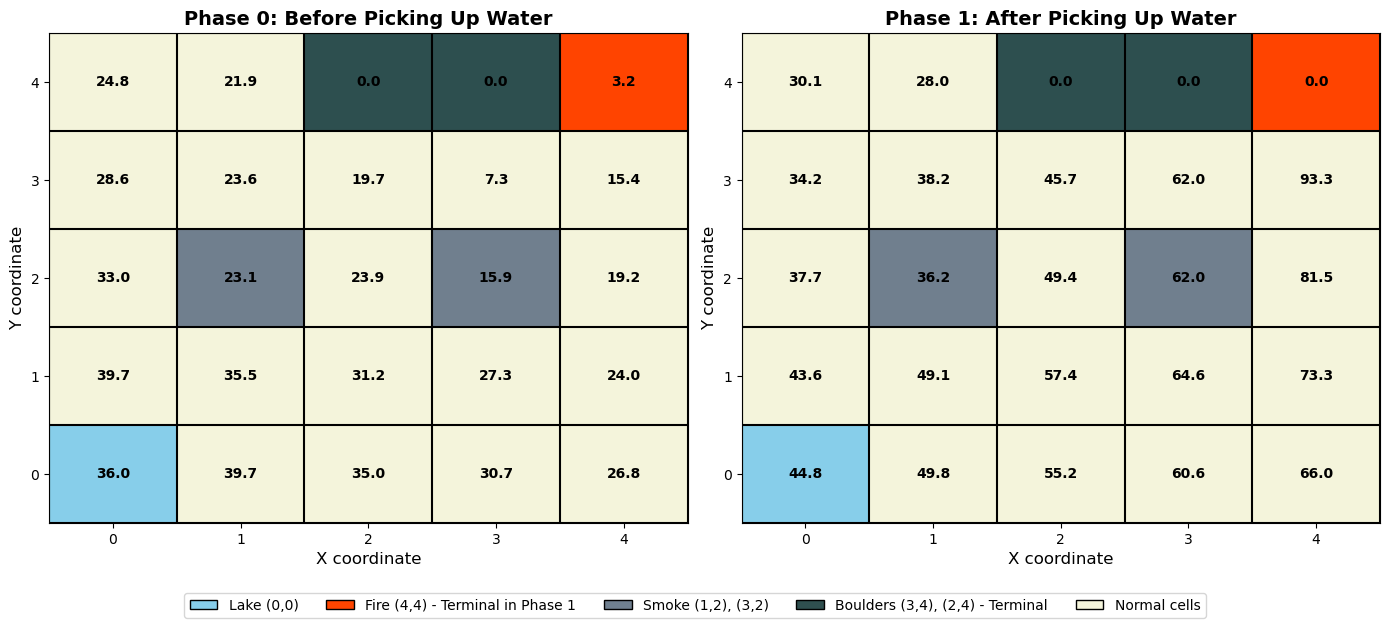

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

def visualize_mdp(gridWorld):
    """
    Visualize both phases of the MDP with special regions highlighted.
    
    Phase 0: Before picking up the key
    Phase 1: After picking up the key
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Define colors for special regions
    colors = {
        'lake': '#87CEEB',      # Sky blue
        'fire': '#FF4500',      # Orange red
        'smoke': '#708090',     # Slate gray
        'boulder': '#2F4F4F',   # Dark slate gray
        'normal': '#F5F5DC'     # Beige
    }
    
    for phase in range(2):
        ax = axes[phase]
        
        # Create a grid to color special regions
        color_grid = np.full((5, 5, 3), [0.96, 0.96, 0.86])  # Default beige color
        
        # Color special regions
        # Lake at (0,0)
        color_grid[0, 0] = [0.53, 0.81, 0.92]  # Sky blue
        
        # Fire at (4,4)
        color_grid[4, 4] = [1.0, 0.27, 0.0]  # Orange red
        
        # Smoke at (1,2) and (3,2)
        color_grid[2, 1] = [0.44, 0.50, 0.56]  # Slate gray
        color_grid[2, 3] = [0.44, 0.50, 0.56]  # Slate gray
        
        # Boulders at (3,4) and (2,4)
        color_grid[4, 3] = [0.18, 0.31, 0.31]  # Dark slate gray
        color_grid[4, 2] = [0.18, 0.31, 0.31]  # Dark slate gray
        
        # Display the grid
        ax.imshow(color_grid, extent=[0, 5, 0, 5], origin='lower', aspect='auto')
        
        # Add grid lines
        for i in range(6):
            ax.axhline(i, color='black', linewidth=1.5)
            ax.axvline(i, color='black', linewidth=1.5)
        
        # Add value function text in each cell
        for i in range(5):
            for j in range(5):
                value = gridWorld[phase, i, j]
                ax.text(i + 0.5, j + 0.5, f'{value:.1f}', 
                       ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Set labels and title
        ax.set_xlim(0, 5)
        ax.set_ylim(0, 5)
        ax.set_xticks(np.arange(0.5, 5.5, 1))
        ax.set_yticks(np.arange(0.5, 5.5, 1))
        ax.set_xticklabels(range(5))
        ax.set_yticklabels(range(5))
        ax.set_xlabel('X coordinate', fontsize=12)
        ax.set_ylabel('Y coordinate', fontsize=12)
        
        if phase == 0:
            ax.set_title('Phase 0: Before Picking Up Water', fontsize=14, fontweight='bold')
        else:
            ax.set_title('Phase 1: After Picking Up Water', fontsize=14, fontweight='bold')
        
        ax.grid(False)
    
    # Create legend
    legend_elements = [
        mpatches.Patch(facecolor='#87CEEB', edgecolor='black', label='Lake (0,0)'),
        mpatches.Patch(facecolor='#FF4500', edgecolor='black', label='Fire (4,4) - Terminal in Phase 1'),
        mpatches.Patch(facecolor='#708090', edgecolor='black', label='Smoke (1,2), (3,2)'),
        mpatches.Patch(facecolor='#2F4F4F', edgecolor='black', label='Boulders (3,4), (2,4) - Terminal'),
        mpatches.Patch(facecolor='#F5F5DC', edgecolor='black', label='Normal cells')
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=5, 
              bbox_to_anchor=(0.5, -0.05), fontsize=10, frameon=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    plt.show()

# Visualize the MDP
visualize_mdp(gridWorld)